<a href="https://colab.research.google.com/github/UrmishaPal/FAERS-Pipeline/blob/main/Modification_of_FAERS_Adverse_Event_Analysis_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FDA FAERS Adverse Event Data Analysis & Pharmacovigilance Pipeline**

**THE PIPELINE WOULD LOOK LIKE**

FDA FAERS ASCII Data
        ↓
Data Extraction
        ↓
Load FAERS Tables
        ↓
Data Quality Checks
        ↓
Cleaning & Standardization
        ↓
Merge Tables
        ↓
Descriptive Pharmacovigilance Analysis
        ↓
Drug–Adverse Event Analysis
        ↓
Demographic Analysis
        ↓
Serious Outcome Analysis
        ↓
Signal Screening
        ↓
Visualizations
        ↓
CSV Results
        ↓
GitHub Repository

**UNDERSTANDING THE RELATIONSHIP**

DEMO
                  |
                  |
               caseid
                  |
       ┌──────────┼──────────┐
       ↓          ↓          ↓
     DRUG       REAC        OUTC
       |
       ↓
      INDI

**DEMO**

primaryid
caseid
age
sex
reporter_country
event_dt

**DRUG**

primaryid
caseid
drug_seq
drugname
prod_ai
role_cod
route
dose

**REAC**

primaryid
caseid
pt

**OUTC**

primaryid
caseid
outc_cod

FAERS is a spontaneous reporting database

**CREATE PROJECT FOLDER**

**FAERS-Pharmacovigilance-Analysis/**

FAERS-Pharmacovigilance-Analysis/
│
├── notebooks/
│   └── FAERS_Analysis.ipynb
│
├── data/
│   └── README.md
│
├── src/
│   └── faers_utils.py
│
├── outputs/
│   ├── figures/
│   └── tables/
│
├── README.md
├── requirements.txt
└── .gitignore

# **IMPORT PYTHON**

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
import os

In [ ]:
import zipfile

In [ ]:
import warnings

warnings.filterwarnings('ignore')

pd.set_option( "display.max_columns", None)
pd.set_option("display.max_rows",100 )

In [ ]:
print ( "Python environment ready !")

Python environment ready !


# **UPLOAD FILE**

In [ ]:
import os

os.listdir("/content")

['.config', 'faers_ascii_2026q2.zip', 'sample_data']

# **EXTRACT ZIP**

In [ ]:
zip_path = "/content/faers_ascii_2026q2.zip"
extract_path = "/content/faers_q2_2026"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed.")

Extraction completed.


In [ ]:
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

/content/faers_q2_2026/Readme.pdf
/content/faers_q2_2026/FAQs.pdf
/content/faers_q2_2026/ASCII/RPSR26Q2.txt
/content/faers_q2_2026/ASCII/DEMO26Q2.txt
/content/faers_q2_2026/ASCII/THER26Q2.pdf
/content/faers_q2_2026/ASCII/DRUG26Q2.txt
/content/faers_q2_2026/ASCII/DRUG26Q2.pdf
/content/faers_q2_2026/ASCII/OUTC26Q2.pdf
/content/faers_q2_2026/ASCII/REAC26Q2.pdf
/content/faers_q2_2026/ASCII/INDI26Q2.txt
/content/faers_q2_2026/ASCII/DEMO26Q2.pdf
/content/faers_q2_2026/ASCII/OUTC26Q2.txt
/content/faers_q2_2026/ASCII/ASC_NTS.pdf
/content/faers_q2_2026/ASCII/THER26Q2.txt
/content/faers_q2_2026/ASCII/REAC26Q2.txt
/content/faers_q2_2026/ASCII/RPSR26Q2.pdf
/content/faers_q2_2026/ASCII/INDI26Q2.pdf
/content/faers_q2_2026/Deleted/DELETE26Q2.txt


# **LOAD DEMO**

In [ ]:
demo_path = "/content/faers_q2_2026/ASCII/DEMO26Q2.txt"

demo = pd.read_csv(
    demo_path,
    sep="$",
    dtype=str,
    encoding="latin1"
)

print(demo.shape)
demo.head()

(422459, 25)


,primaryid,caseid,caseversion,i_f_code,event_dt,mfr_dt,init_fda_dt,fda_dt,rept_cod,auth_num,mfr_num,mfr_sndr,lit_ref,age,age_cod,age_grp,sex,e_sub,wt,wt_cod,rept_dt,to_mfr,occp_cod,reporter_country,occr_country
0,100140224,10014022,4,F,NaN,20260508,20140317,20260513,EXP,NaN,EU-ROCHE-1347273,ROCHE,NaN,66,YR,E,M,Y,83,KG,20260513,NaN,MD,EU,EU
1,100218353,10021835,3,F,NaN,20260528,20140319,20260603,EXP,NaN,US-JNJFOC-20131202728,JOHNSON AND JOHNSON,NaN,13,YR,T,M,Y,NaN,NaN,20260603,NaN,LW,US,US
2,101009832,10100983,2,F,NaN,20140402,20140424,20260624,EXP,NaN,EU-JNJFOC-20140412726,Kenvue,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,20260624,NaN,MD,EU,EU
3,101447083,10144708,3,F,NaN,20130103,20251230,20251230,PER,NaN,US-SANOFI-AVENTIS-2013SA001163,VALIDUS,NaN,48,YR,NaN,NaN,Y,NaN,NaN,20260628,NaN,NaN,US,NaN
4,101447143,10144714,3,F,NaN,20140321,20251230,20251230,PER,NaN,US-SANOFI-AVENTIS-2013SA022575,VALIDUS,NaN,85,YR,NaN,NaN,Y,NaN,NaN,20260628,NaN,NaN,US,NaN


# **LOAD DRUG**

In [ ]:
drug_path = "/content/faers_q2_2026/ASCII/DRUG26Q2.txt"

drug = pd.read_csv(
    drug_path,
    sep="$",
    dtype=str,
    encoding="latin1"
)

print(drug.shape)
drug.head()

(1627225, 20)


,primaryid,caseid,drug_seq,role_cod,drugname,prod_ai,val_vbm,route,dose_vbm,cum_dose_chr,cum_dose_unit,dechal,rechal,lot_num,exp_dt,nda_num,dose_amt,dose_unit,dose_form,dose_freq
0,100140224,10014022,1,PS,PEGINTERFERON ALFA-2A,PEGINTERFERON ALFA-2A,1,Subcutaneous,NaN,NaN,NaN,Y,U,NaN,NaN,NaN,180,UG,Solution for injection,/WK
1,100140224,10014022,2,SS,COPEGUS,RIBAVIRIN,1,Oral,NaN,NaN,NaN,Y,U,NaN,NaN,NaN,1200,MG,"TABLET, FILM COATED",QD
2,100140224,10014022,3,SS,VICTRELIS,BOCEPREVIR,1,Oral,NaN,NaN,NaN,Y,U,NaN,NaN,NaN,2400,MG,"Capsule, hard",QD
3,100140224,10014022,4,C,CAPTOPRIL,CAPTOPRIL,1,NaN,NaN,NaN,NaN,U,NaN,NaN,NaN,NaN,25,MG,NaN,QD
4,100140224,10014022,5,C,METFORMIN,METFORMIN HYDROCHLORIDE,1,Oral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500,MG,NaN,NaN


# **LOAD REAC**

In [ ]:
reac_path = "/content/faers_q2_2026/ASCII/REAC26Q2.txt"

reac = pd.read_csv(
    reac_path,
    sep="$",
    dtype=str,
    encoding="latin1"
)

print(reac.shape)
reac.head()

(1394751, 4)


,primaryid,caseid,pt,drug_rec_act
0,100140224,10014022,Toxic skin eruption,NaN
1,100218353,10021835,Emotional disorder,NaN
2,100218353,10021835,Gynaecomastia,NaN
3,100218353,10021835,Weight increased,NaN
4,100218353,10021835,Tardive dyskinesia,NaN


# **LOAD OUTC**

In [ ]:
outc_path = "/content/faers_q2_2026/ASCII/OUTC26Q2.txt"

outc = pd.read_csv(
    outc_path,
    sep="$",
    dtype=str,
    encoding="latin1"
)

print(outc.shape)
outc.head()

(303705, 3)


,primaryid,caseid,outc_cod
0,100140224,10014022,OT
1,100218353,10021835,OT
2,101009832,10100983,CA
3,101009832,10100983,OT
4,101448952,10144895,OT


# **LOAD INDI**

In [ ]:
indi_path = "/content/faers_q2_2026/ASCII/INDI26Q2.txt"

indi = pd.read_csv(
    indi_path,
    sep="$",
    dtype=str,
    encoding="latin1"
)

print(indi.shape)
indi.head()

(1124333, 4)


,primaryid,caseid,indi_drug_seq,indi_pt
0,100140224,10014022,1,Hepatitis C
1,100140224,10014022,2,Hepatitis C
2,100140224,10014022,3,Hepatitis C
3,100218353,10021835,1,Bipolar disorder
4,100218353,10021835,1,Attention deficit hyperactivity disorder


In [ ]:
indi_path = "/content/faers_q2_2026/ASCII/INDI26Q2.txt"

indi = pd.read_csv(
    indi_path,
    sep="$",
    dtype=str,
    encoding="latin1"
)

print(indi.shape)
indi.head()

(1124333, 4)


,primaryid,caseid,indi_drug_seq,indi_pt
0,100140224,10014022,1,Hepatitis C
1,100140224,10014022,2,Hepatitis C
2,100140224,10014022,3,Hepatitis C
3,100218353,10021835,1,Bipolar disorder
4,100218353,10021835,1,Attention deficit hyperactivity disorder


# **FIRST MAJOR DATA QUALITY CHECK**

In [ ]:
datasets = {
    "DEMO": demo,
    "DRUG": drug,
    "REAC": reac,
    "OUTC": outc,
    "INDI": indi
}

for name, df in datasets.items():
    print(
        name,
        "Rows:", df.shape[0],
        "Columns:", df.shape[1]
    )

DEMO Rows: 422459 Columns: 25
DRUG Rows: 1627225 Columns: 20
REAC Rows: 1394751 Columns: 4
OUTC Rows: 303705 Columns: 3
INDI Rows: 1124333 Columns: 4


In [ ]:
datasets = {
    "DEMO": demo,
    "DRUG": drug,
    "REAC": reac,
    "OUTC": outc,
    "INDI": indi
}

for name, df in datasets.items():
    print(
        name,
        "Rows:", df.shape[0],
        "Columns:", df.shape[1]
    )

DEMO Rows: 422459 Columns: 25
DRUG Rows: 1627225 Columns: 20
REAC Rows: 1394751 Columns: 4
OUTC Rows: 303705 Columns: 3
INDI Rows: 1124333 Columns: 4


# **INSPECT COLUMN NAMES**

In [ ]:
for name, df in datasets.items():
    print("\n", "="*50)
    print(name)
    print(df.columns.tolist())


DEMO
['primaryid', 'caseid', 'caseversion', 'i_f_code', 'event_dt', 'mfr_dt', 'init_fda_dt', 'fda_dt', 'rept_cod', 'auth_num', 'mfr_num', 'mfr_sndr', 'lit_ref', 'age', 'age_cod', 'age_grp', 'sex', 'e_sub', 'wt', 'wt_cod', 'rept_dt', 'to_mfr', 'occp_cod', 'reporter_country', 'occr_country']

DRUG
['primaryid', 'caseid', 'drug_seq', 'role_cod', 'drugname', 'prod_ai', 'val_vbm', 'route', 'dose_vbm', 'cum_dose_chr', 'cum_dose_unit', 'dechal', 'rechal', 'lot_num', 'exp_dt', 'nda_num', 'dose_amt', 'dose_unit', 'dose_form', 'dose_freq']

REAC
['primaryid', 'caseid', 'pt', 'drug_rec_act']

OUTC
['primaryid', 'caseid', 'outc_cod']

INDI
['primaryid', 'caseid', 'indi_drug_seq', 'indi_pt']


# **MISSING VALUE ANALYSIS**

In [ ]:
def missing_summary(df):
    result = pd.DataFrame({
        "Missing_Count": df.isna().sum(),
        "Missing_Percentage":
            (df.isna().mean() * 100).round(2)
    })

    return result.sort_values(
        "Missing_Percentage",
        ascending=False
    )

# **MISSING SUMMARY**

In [ ]:
missing_summary(demo).head(15)

,Missing_Count,Missing_Percentage
lit_ref,410301,97.12
to_mfr,408882,96.79
auth_num,382647,90.58
wt,349513,82.73
wt_cod,349511,82.73
occp_cod,304677,72.12
age_grp,300412,71.11
event_dt,245986,58.23
age,156207,36.98
age_cod,156207,36.98


In [ ]:
missing_summary(drug).head(15)

,Missing_Count,Missing_Percentage
exp_dt,1623596,99.78
cum_dose_unit,1599003,98.27
cum_dose_chr,1599003,98.27
dose_form,1299244,79.84
lot_num,1287546,79.13
dose_freq,1255007,77.13
rechal,1202605,73.91
nda_num,1072560,65.91
route,1013885,62.31
dose_unit,977829,60.09


In [ ]:
missing_summary(reac).head(15)

,Missing_Count,Missing_Percentage
drug_rec_act,1390978,99.73
primaryid,0,0.00
caseid,0,0.00
pt,0,0.00


# **CHECK DUPLICATES**

In [ ]:
print("DEMO duplicate rows:", demo.duplicated().sum())
print("DRUG duplicate rows:", drug.duplicated().sum())
print("REAC duplicate rows:", reac.duplicated().sum())

DEMO duplicate rows: 0
DRUG duplicate rows: 1034
REAC duplicate rows: 20723


# **STANDADIZE COLOUMN NAMES**

In [ ]:
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df

In [ ]:
demo = clean_columns(demo)
drug = clean_columns(drug)
reac = clean_columns(reac)
outc = clean_columns(outc)
indi = clean_columns(indi)

In [ ]:
demo.columns

Index(['primaryid', 'caseid', 'caseversion', 'i_f_code', 'event_dt', 'mfr_dt',
       'init_fda_dt', 'fda_dt', 'rept_cod', 'auth_num', 'mfr_num', 'mfr_sndr',
       'lit_ref', 'age', 'age_cod', 'age_grp', 'sex', 'e_sub', 'wt', 'wt_cod',
       'rept_dt', 'to_mfr', 'occp_cod', 'reporter_country', 'occr_country'],
      dtype='object')

# **CLEAN TEXT FEILDS**

In [ ]:
def clean_text_columns(df):
    df = df.copy()

    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip()
        df[col] = df[col].replace(
            ["", "NULL", "null", "N/A", "NA"],
            np.nan
        )

    return df

In [ ]:
demo = clean_text_columns(demo)
drug = clean_text_columns(drug)
reac = clean_text_columns(reac)
outc = clean_text_columns(outc)
indi = clean_text_columns(indi)

# **CLEAN DRUG NAMES**

In [ ]:
drug["drugname_clean"] = (
    drug["drugname"]
    .str.lower()
    .str.strip()
)

In [ ]:
drug["drugname_clean"].value_counts().head(20)

,count
drugname_clean,
dupixent,54979
prednisone,18495
zepbound,16781
methotrexate,15953
ozempic,12686
rituximab,11996
acetaminophen,11004
aspirin,10744
inflectra,9685


# **UNDERSTAND ROLE COD**

In [ ]:
drug["role_cod"].value_counts(dropna=False)

,count
role_cod,
C,635555
PS,530352
SS,452731
I,8141
DN,446


In [ ]:
role_map = {
    "PS": "Primary Suspect",
    "SS": "Secondary Suspect",
    "C": "Concomitant",
    "I": "Interacting"
}

drug["role_description"] = drug["role_cod"].map(role_map)

In [ ]:
drug[
    ["role_cod", "role_description"]
].drop_duplicates()

,role_cod,role_description
0,PS,Primary Suspect
1,SS,Secondary Suspect
3,C,Concomitant
697,I,Interacting
6688,DN,NaN


# **ANALYZE REPORTED ADVERSE EVENTS**

In [ ]:
top_reactions = (
    reac["pt"]
    .value_counts()
    .head(20)
)

top_reactions

,count
pt,
Off label use,27173
Drug ineffective,23717
Nausea,18283
Fatigue,17735
Product dose omission issue,17549
Diarrhoea,17089
Pruritus,14485
Death,13470
Headache,13082


# **VISUALIZE TOP ADVERSE EVENTS**

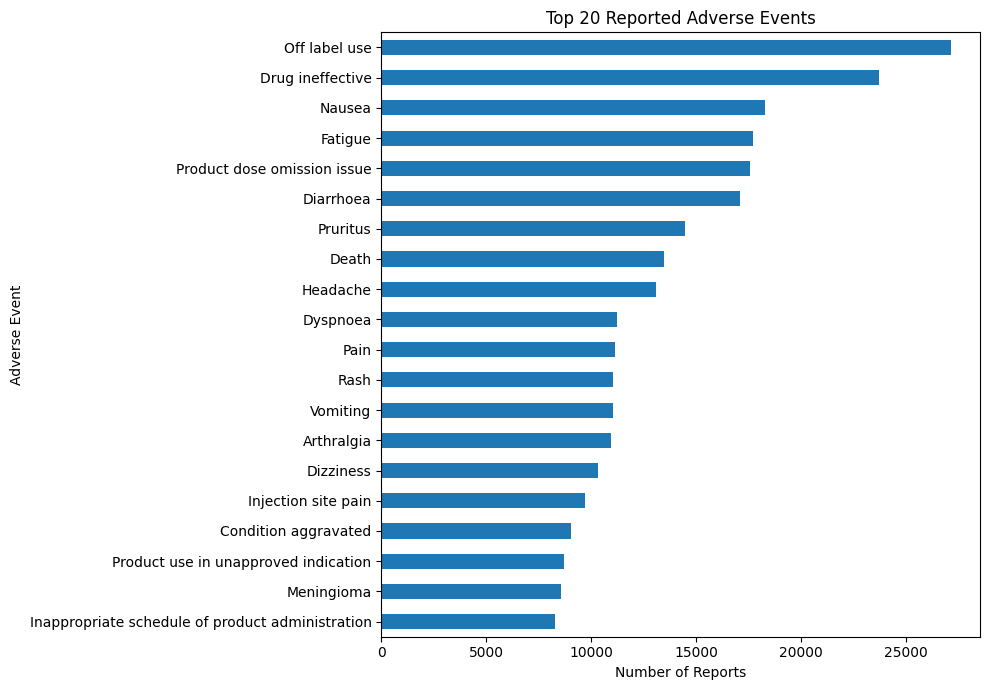

In [ ]:
plt.figure(figsize=(10, 7))

top_reactions.sort_values().plot(
    kind="barh"
)

plt.title("Top 20 Reported Adverse Events")
plt.xlabel("Number of Reports")
plt.ylabel("Adverse Event")

plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(
    "/content/top_adverse_events.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# **ANALYZE MOST FREQUENTLY REPORTED DRUGS**

In [ ]:
top_drugs = (
    drug["drugname_clean"]
    .value_counts()
    .head(20)
)

top_drugs

,count
drugname_clean,
dupixent,54979
prednisone,18495
zepbound,16781
methotrexate,15953
ozempic,12686
rituximab,11996
acetaminophen,11004
aspirin,10744
inflectra,9685


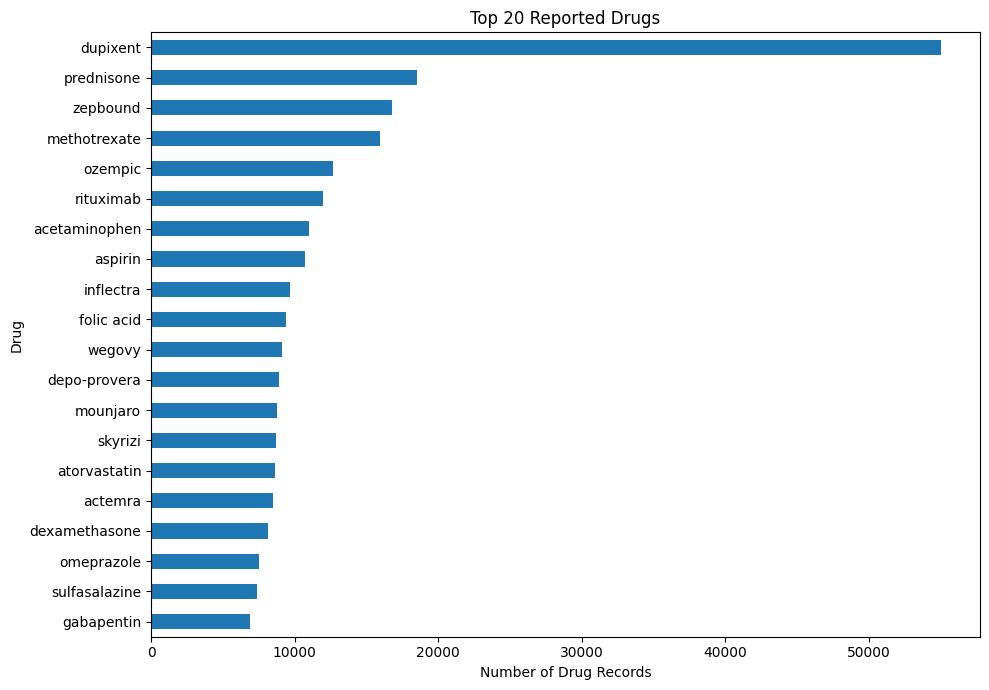

In [ ]:
plt.figure(figsize=(10, 7))

top_drugs.sort_values().plot(
    kind="barh"
)

plt.title("Top 20 Reported Drugs")
plt.xlabel("Number of Drug Records")
plt.ylabel("Drug")

plt.tight_layout()
plt.show()

# **PRIMARY SUSPECT DRUG ANALYSIS**

In [ ]:
primary_suspect = drug[
    drug["role_cod"] == "PS"
]

primary_suspect_counts = (
    primary_suspect["drugname_clean"]
    .value_counts()
    .head(20)
)

primary_suspect_counts

,count
drugname_clean,
dupixent,54056
zepbound,13757
ozempic,9996
depo-provera,8833
wegovy,7625
bimzelx,6261
mounjaro,6169
tymlos,5640
skyrizi,5594


# **ANALYZE PATIENT DEMOGRAPHICS**

In [ ]:
demo["sex"].value_counts(dropna=False)

,count
sex,
F,213184
M,129856
NaN,79419


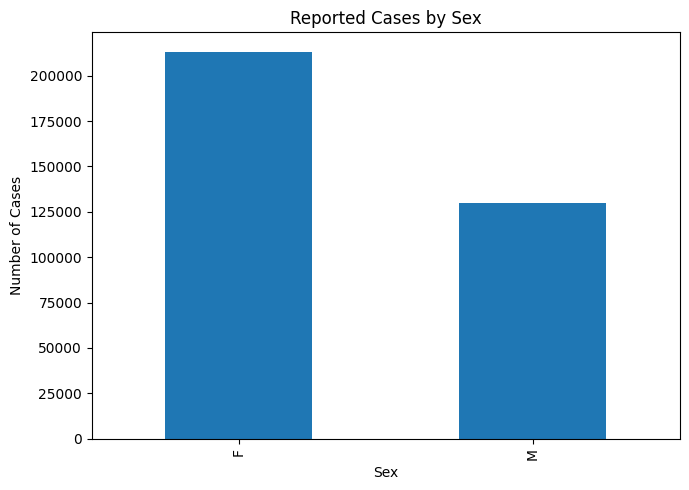

In [ ]:
plt.figure(figsize=(7, 5))

demo["sex"].value_counts().plot(
    kind="bar"
)

plt.title("Reported Cases by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Cases")

plt.tight_layout()
plt.show()

# **AGE ANALYSIS**

In [ ]:
demo[["age", "age_cod"]].head()

,age,age_cod
0,66,YR
1,13,YR
2,NaN,NaN
3,48,YR
4,85,YR


In [ ]:
demo["age_numeric"] = pd.to_numeric(
    demo["age"],
    errors="coerce"
)

In [ ]:
demo["age_cod"].value_counts(dropna=False)

,count
age_cod,
YR,260429
NaN,156207
DEC,4185
MON,1229
DY,286
WK,105
HR,18


# **CONVERT AGE INTO YEARS**

In [ ]:
def convert_age(row):
    age = pd.to_numeric(row["age"], errors="coerce")
    unit = row["age_cod"]

    if pd.isna(age):
        return np.nan

    if unit == "YR":
        return age

    elif unit == "MON":
        return age / 12

    elif unit == "WK":
        return age / 52

    elif unit == "DY":
        return age / 365

    return np.nan

# **CREATE AGE GROUPS**

In [ ]:
demo['age_years'] = demo.apply(convert_age, axis=1)

bins = [0, 18, 30, 45, 60, 75, 200]

labels = [
    "<18",
    "18-29",
    "30-44",
    "45-59",
    "60-74",
    "75+"
]

demo["age_group"] = pd.cut(
    demo["age_years"],
    bins=bins,
    labels=labels,
    right=False
)

In [ ]:
demo["age_group"].value_counts().sort_index()

,count
age_group,
<18,19580
18-29,18745
30-44,36241
45-59,55110
60-74,82604
75+,49769


# **ANALYZE REPORTING COUNTRIES**

In [ ]:
country_counts = (
    demo["reporter_country"]
    .value_counts()
    .head(15)
)

country_counts

,count
reporter_country,
US,285577
EU,42030
CA,17578
JP,15518
GB,15115
COUNTRY NOT SPECIFIED,10163
CN,9582
CO,3240
AU,2924


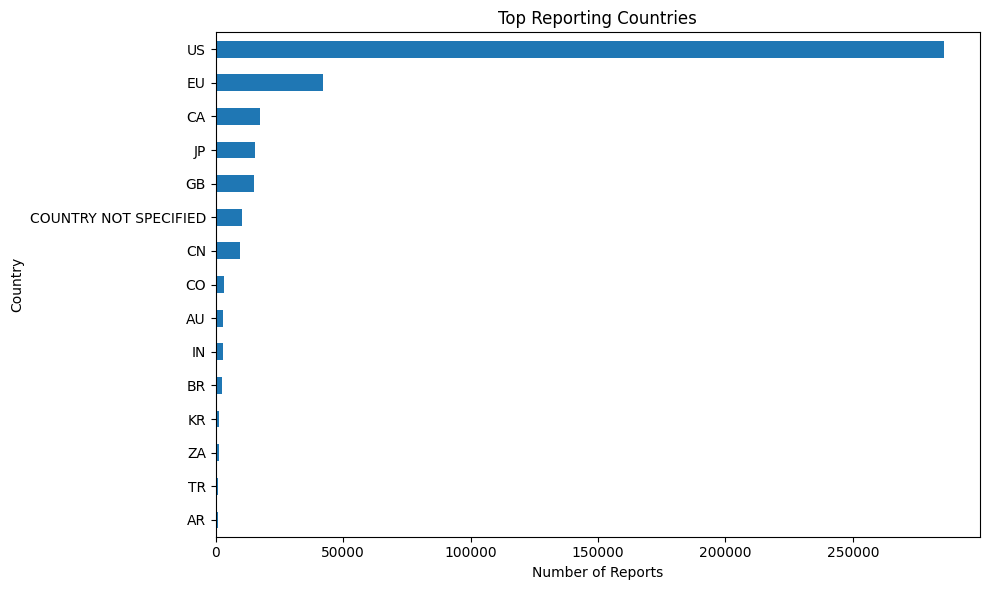

In [ ]:
plt.figure(figsize=(10, 6))

country_counts.sort_values().plot(
    kind="barh"
)

plt.title("Top Reporting Countries")
plt.xlabel("Number of Reports")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

# **ANALYZE OUTCOMES**

In [ ]:
outc["outc_cod"].value_counts()

,count
outc_cod,
OT,168785
HO,83615
DE,28330
LT,13195
DS,6336
RI,1775
CA,1669


In [ ]:
outcome_map = {
    "DE": "Death",
    "LT": "Life-Threatening",
    "HO": "Hospitalization",
    "DS": "Disability",
    "CA": "Congenital Anomaly",
    "RI": "Required Intervention",
    "OT": "Other Serious Outcome"
}

outc["outcome_description"] = outc["outc_cod"].map(
    outcome_map
)

In [ ]:
outc["outcome_description"].value_counts()

,count
outcome_description,
Other Serious Outcome,168785
Hospitalization,83615
Death,28330
Life-Threatening,13195
Disability,6336
Required Intervention,1775
Congenital Anomaly,1669


# **DO NOT DOUBLE COUNT OUTCOMES**

In [ ]:
outc["caseid"].nunique()

230766

In [ ]:
outc_path = "/content/faers_q2_2026/ASCII/OUTC26Q2.txt"

outc = pd.read_csv(
    outc_path,
    sep="$",
    dtype=str,
    encoding="latin1"
)

def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df

def clean_text_columns(df):
    df = df.copy()

    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip()
        df[col] = df[col].replace(
            ["", "NULL", "null", "N/A", "NA"],
            np.nan
        )

    return df

outc = clean_columns(outc)
outc = clean_text_columns(outc)

len(outc)

303705

# **MERGE DEMO+DRUG**

In [ ]:
demo_drug = demo.merge(
    drug,
    on=["primaryid", "caseid"],
    how="inner",
    suffixes=("_demo", "_drug")
)

print(demo_drug.shape)

(1627225, 45)


In [ ]:
import pandas as pd
import numpy as np
import os
import zipfile

zip_path = "/content/faers_ascii_2026q2.zip"
extract_path = "/content/faers_q2_2026"

# Ensure the data is extracted
if not os.path.exists(extract_path):
    print("Extracting FAERS data...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction completed.")
else:
    print("FAERS data already extracted.")

demo_path = "/content/faers_q2_2026/ASCII/DEMO26Q2.txt"
drug_path = "/content/faers_q2_2026/ASCII/DRUG26Q2.txt"
reac_path = "/content/faers_q2_2026/ASCII/REAC26Q2.txt"

# Reload demo dataframe
demo = pd.read_csv(
    demo_path,
    sep="$",
    dtype=str,
    encoding="latin1"
)

# Reload drug dataframe
drug = pd.read_csv(
    drug_path,
    sep="$",
    dtype=str,
    encoding="latin1"
)

# Reload reac dataframe
reac = pd.read_csv(
    reac_path,
    sep="$",
    dtype=str,
    encoding="latin1"
)

# Re-apply cleaning functions
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df

def clean_text_columns(df):
    df = df.copy()

    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip()
        df[col] = df[col].replace(
            ["", "NULL", "null", "N/A", "NA"],
            np.nan
        )

    return df

demo = clean_columns(demo)
drug = clean_columns(drug)
reac = clean_columns(reac)

demo = clean_text_columns(demo)
drug = clean_text_columns(drug)
reac = clean_text_columns(reac)

# Re-create drugname_clean column
drug["drugname_clean"] = (
    drug["drugname"]
    .str.lower()
    .str.strip()
)

# Re-create role_description column
role_map = {
    "PS": "Primary Suspect",
    "SS": "Secondary Suspect",
    "C": "Concomitant",
    "I": "Interacting"
}
drug["role_description"] = drug["role_cod"].map(role_map)

print("DataFrames `demo`, `drug`, `reac` reloaded and cleaned.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/faers_q2_2026/ASCII/DEMO26Q2.txt'

In [ ]:
case_drug_reac = demo_drug.merge(
    reac,
    on=["primaryid", "caseid"],
    how="inner"
)

print(case_drug_reac.shape)

NameError: name 'demo_drug' is not defined

In [ ]:
demo_drug = demo.merge(
    drug,
    on=["primaryid", "caseid"],
    how="inner",
    suffixes=("_demo", "_drug")
)

print("Shape of demo_drug:", demo_drug.shape)


NameError: name 'demo' is not defined

In [ ]:
case_drug_reac = demo_drug.merge(
    reac,
    on=["primaryid", "caseid"],
    how="inner"
)

print("Shape of case_drug_reac:", case_drug_reac.shape)


NameError: name 'demo_drug' is not defined